In [ ]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve, 
    classification_report, confusion_matrix
)
from pathlib import Path


In [8]:
# multiclass
path = '../interm/metrics/multiclass_graphSAGE_unsw_train_20260212_225724/Multiclass_graphSAGE_unsw_train.pkl'
with open(path, "rb") as f:
    metrics = pickle.load(f)

metrics.keys()

dict_keys(['le', 'train_info', 'test_info', 'description', 'model'])

classificaiton report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       443
           1       0.00      0.00      0.00       918
           2       0.93      1.00      0.97    418905
           3       0.00      0.00      0.00      1662
           4       0.00      0.00      0.00     12969
           5       0.00      0.00      0.00      7475
           6       0.00      0.00      0.00      1672
           7       0.00      0.00      0.00      4156
           8       0.00      0.00      0.00       343
           9       0.00      0.00      0.00        44

    accuracy                           0.93    448587
   macro avg       0.09      0.10      0.10    448587
weighted avg       0.87      0.93      0.90    448587

conf matrix > 0.5
value counts:
(array([2]), array([448587]))


c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


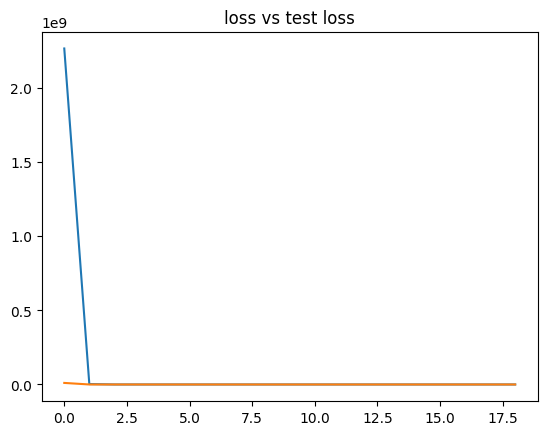

In [42]:
def extract_info(info):
    sum_loss = 0
    ys, y_preds = [], []
    for epoch, epoch_info in enumerate(info):
        loss, y_pred, y = epoch_info 
        ys.append(y)
        y_preds.append(y_pred)
        sum_loss += loss

    return (ys, y_preds, sum_loss / len(info))

def plot_roc(test_info):
    loss, y_pred, y = test_info 
    auc = roc_auc_score(y, y_pred),
    print(f"Test AUC: {auc:.4f}")
    fpr, tpr, _ = roc_curve(y, y_pred)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.show()

test_losses, train_losses, test_aucs, train_aucs = [], [], [], [] 
for ((train_info), (test_info)) in zip(
    metrics['train_info'], metrics['test_info']
):
    ys, y_preds, av_loss = extract_info(train_info)
    test_ys, test_y_preds, test_av_loss = extract_info(test_info)

    train_losses.append(av_loss)
    test_losses.append(test_av_loss)
    # train_aucs.append(tr_ex['auc'])
    # test_aucs.append(te_ex['auc'])

plt.title('loss vs test loss')
plt.plot(train_losses)
plt.plot(test_losses)

# eval last test run
print('classificaiton report')
test_y_preds = np.vstack(test_y_preds)
test_ys = np.hstack(test_ys)
print(classification_report(test_ys, test_y_preds.argmax(axis=1)))
print('conf matrix > 0.5')
# print(confusion_matrix(ys, test_y_preds.argmax(axis=1)))

print('value counts:')
print(np.unique(test_y_preds.argmax(axis=1), return_counts=True))
# auc = roc_auc_score(ys, y_preds)
# print(f"Test AUC: {auc:.4f}")
# fpr, tpr, _ = roc_curve(ys, y_preds)
# plt.figure()
# plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title(f"ROC Curve")
# plt.legend(loc='lower right')
# plt.show()


    

<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\20757218\AppData\Local\Temp\ipykernel_14912\646528463.py:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  metrics_path = Path('../interm\metrics\graphSAGE_unsw_train_20260212_165310')




 ==== Metrics for Analysis_graphSAGE_unsw_train ====
Description: Binary classification on Analysis - GraphSAGE with linegraph on UNSW-NB15 dataset
Final Train Loss: 6880892.0964
Final Test Loss: 1568784.2500
positive samples: 443 / 448587
predicted positive samples: 0 / 448587
Test AUC: 0.5000


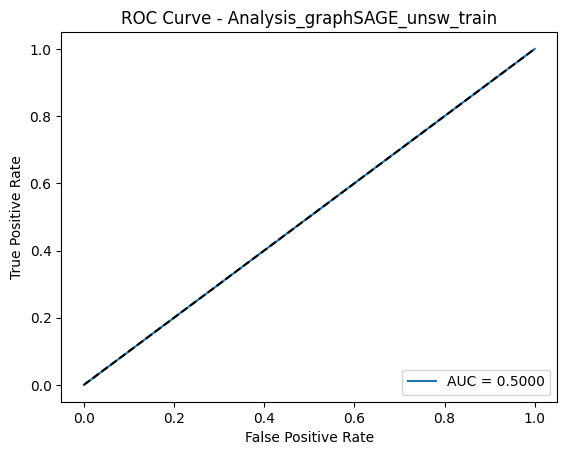

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    448144
           1       0.00      0.00      0.00       443

    accuracy                           1.00    448587
   macro avg       0.50      0.50      0.50    448587
weighted avg       1.00      1.00      1.00    448587

Confusion Matrix (threshold=0.5):
[[448144      0]
 [   443      0]]


c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])




 ==== Metrics for Backdoor_graphSAGE_unsw_train ====
Description: Binary classification on Backdoor - GraphSAGE with linegraph on UNSW-NB15 dataset
Final Train Loss: 6093630.7965
Final Test Loss: 1603126.5000
positive samples: 918 / 448587
predicted positive samples: 0 / 448587
Test AUC: 0.5000


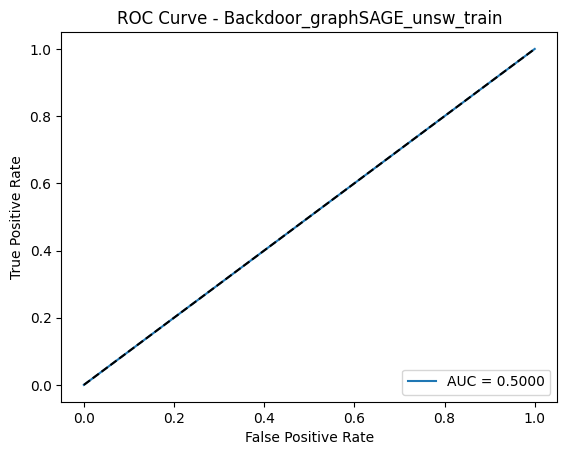

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    447669
           1       0.00      0.00      0.00       918

    accuracy                           1.00    448587
   macro avg       0.50      0.50      0.50    448587
weighted avg       1.00      1.00      1.00    448587

Confusion Matrix (threshold=0.5):
[[447669      0]
 [   918      0]]


c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])




 ==== Metrics for DoS_graphSAGE_unsw_train ====
Description: Binary classification on DoS - GraphSAGE with linegraph on UNSW-NB15 dataset
Final Train Loss: 50119218.5786
Final Test Loss: 22910606.0000
positive samples: 1662 / 448587
predicted positive samples: 0 / 448587
Test AUC: 0.5000


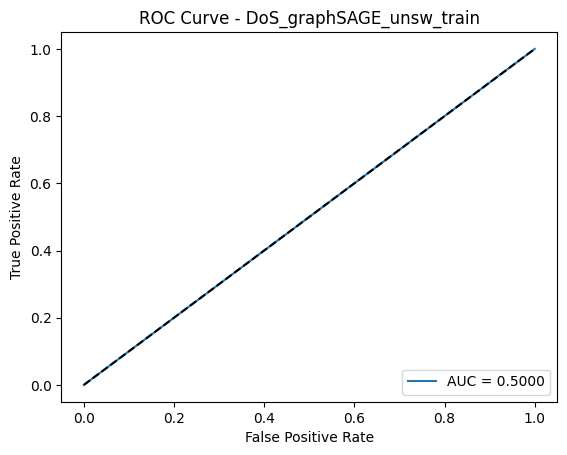

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    446925
           1       0.00      0.00      0.00      1662

    accuracy                           1.00    448587
   macro avg       0.50      0.50      0.50    448587
weighted avg       0.99      1.00      0.99    448587

Confusion Matrix (threshold=0.5):
[[446925      0]
 [  1662      0]]


c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])




 ==== Metrics for Exploits_graphSAGE_unsw_train ====
Description: Binary classification on Exploits - GraphSAGE with linegraph on UNSW-NB15 dataset
Final Train Loss: 287001416.7160
Final Test Loss: 100213776.0000
positive samples: 12969 / 448587
predicted positive samples: 0 / 448587
Test AUC: 0.5000


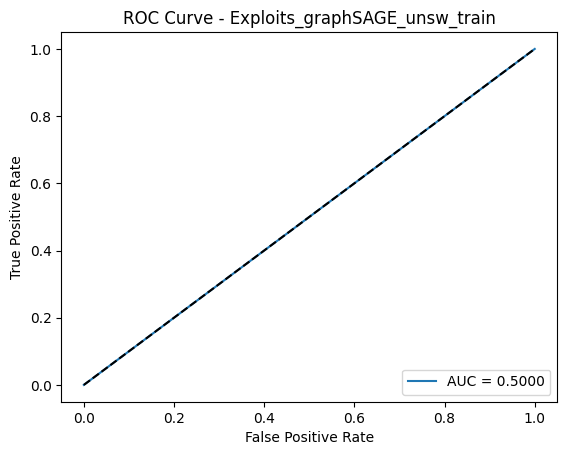

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.97      1.00      0.99    435618
           1       0.00      0.00      0.00     12969

    accuracy                           0.97    448587
   macro avg       0.49      0.50      0.49    448587
weighted avg       0.94      0.97      0.96    448587

Confusion Matrix (threshold=0.5):
[[435618      0]
 [ 12969      0]]


c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])




 ==== Metrics for Fuzzers_graphSAGE_unsw_train ====
Description: Binary classification on Fuzzers - GraphSAGE with linegraph on UNSW-NB15 dataset
Final Train Loss: 4055607281.6539
Final Test Loss: 4777536000.0000
positive samples: 7475 / 448587
predicted positive samples: 0 / 448587
Test AUC: 0.5000


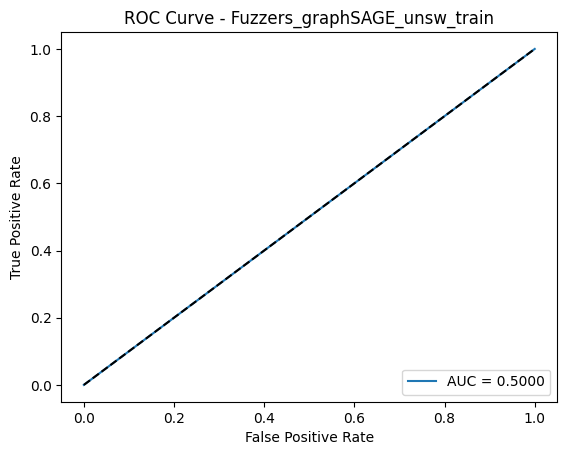

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    441112
           1       0.00      0.00      0.00      7475

    accuracy                           0.98    448587
   macro avg       0.49      0.50      0.50    448587
weighted avg       0.97      0.98      0.98    448587

Confusion Matrix (threshold=0.5):
[[441112      0]
 [  7475      0]]


c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])




 ==== Metrics for Generic_graphSAGE_unsw_train ====
Description: Binary classification on Generic - GraphSAGE with linegraph on UNSW-NB15 dataset
Final Train Loss: 163308442.0100
Final Test Loss: 31516856.0000
positive samples: 1672 / 448587
predicted positive samples: 0 / 448587
Test AUC: 0.5000


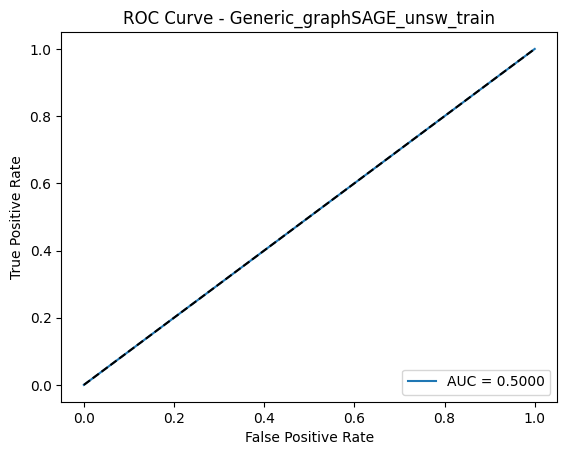

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    446915
           1       0.00      0.00      0.00      1672

    accuracy                           1.00    448587
   macro avg       0.50      0.50      0.50    448587
weighted avg       0.99      1.00      0.99    448587

Confusion Matrix (threshold=0.5):
[[446915      0]
 [  1672      0]]


c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])




 ==== Metrics for Reconnaissance_graphSAGE_unsw_train ====
Description: Binary classification on Reconnaissance - GraphSAGE with linegraph on UNSW-NB15 dataset
Final Train Loss: 113386946.4099
Final Test Loss: 13769092.0000
positive samples: 4156 / 448587
predicted positive samples: 0 / 448587
Test AUC: 0.5000


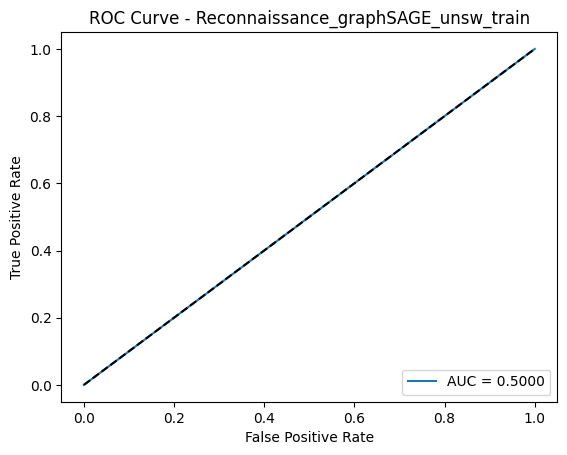

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    444431
           1       0.00      0.00      0.00      4156

    accuracy                           0.99    448587
   macro avg       0.50      0.50      0.50    448587
weighted avg       0.98      0.99      0.99    448587

Confusion Matrix (threshold=0.5):
[[444431      0]
 [  4156      0]]


c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])




 ==== Metrics for Shellcode_graphSAGE_unsw_train ====
Description: Binary classification on Shellcode - GraphSAGE with linegraph on UNSW-NB15 dataset
Final Train Loss: 46034883.6996
Final Test Loss: 1533533.1250
positive samples: 343 / 448587
predicted positive samples: 0 / 448587
Test AUC: 0.5000


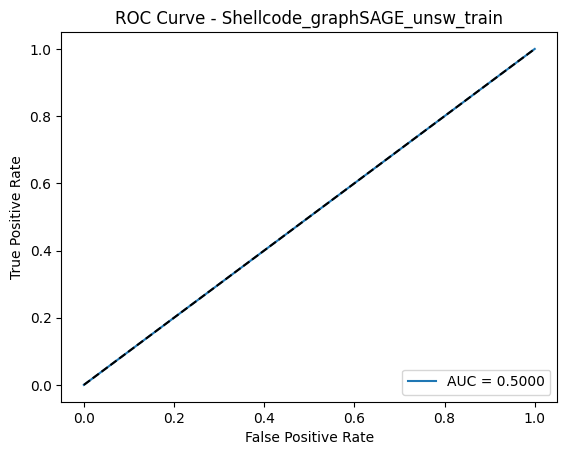

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    448244
           1       0.00      0.00      0.00       343

    accuracy                           1.00    448587
   macro avg       0.50      0.50      0.50    448587
weighted avg       1.00      1.00      1.00    448587

Confusion Matrix (threshold=0.5):
[[448244      0]
 [   343      0]]


c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])




 ==== Metrics for Worms_graphSAGE_unsw_train ====
Description: Binary classification on Worms - GraphSAGE with linegraph on UNSW-NB15 dataset
Final Train Loss: 31613613.8492
Final Test Loss: 36328.5820
positive samples: 44 / 448587
predicted positive samples: 0 / 448587
Test AUC: 0.5000


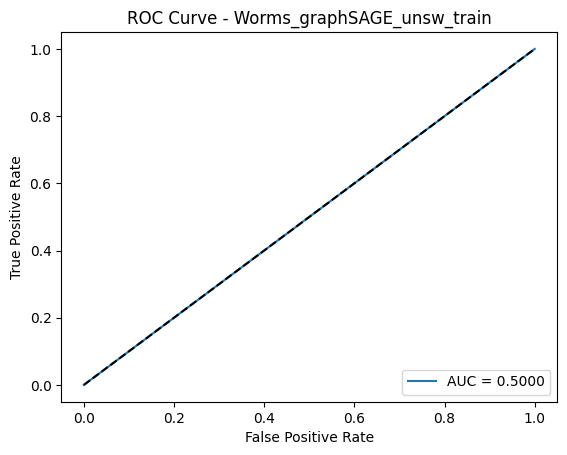

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    448543
           1       0.00      0.00      0.00        44

    accuracy                           1.00    448587
   macro avg       0.50      0.50      0.50    448587
weighted avg       1.00      1.00      1.00    448587

Confusion Matrix (threshold=0.5):
[[448543      0]
 [    44      0]]


c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\working\xai_gnn_nids_hdr1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:

# binary
metrics_path = Path('../interm\metrics\graphSAGE_unsw_train_20260212_165310')
for metric_file in metrics_path.glob("*.pkl"):
    with open(metric_file, "rb") as f:
        metrics = pickle.load(f)

    print(f"\n\n ==== Metrics for {metric_file.stem} ====")
    print(f"Description: {metrics['description']}")
    print(f"Final Train Loss: {metrics['train_losses'][-1]:.4f}")
    print(f"Final Test Loss: {metrics['test_losses'][-1]:.4f}")

    ys, y_preds = metrics['test predictions']

    # vstack ys and y_preds if they are lists of arrys
    if isinstance(ys, list):
        ys = np.hstack(ys)
    if isinstance(y_preds, list):
        y_preds = np.hstack(y_preds)

    print(f'positive samples: {np.sum(ys)} / {len(ys)}')
    print(f'predicted positive samples: {np.sum(y_preds >= 0.5)} / {len(y_preds)}')

    auc = roc_auc_score(ys, y_preds)
    print(f"Test AUC: {auc:.4f}")
    fpr, tpr, _ = roc_curve(ys, y_preds)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f"ROC Curve - {metric_file.stem}")
    plt.legend(loc='lower right')
    plt.show()

    # classification report at 0.5 threshold
    y_pred_labels = (y_preds >= 0.5).astype(int)
    print("Classification Report (threshold=0.5):")
    print(classification_report(ys, y_pred_labels))
    print("Confusion Matrix (threshold=0.5):")
    print(confusion_matrix(ys, y_pred_labels))

